# 🧠 BRISC 2025: Dataset Overview**

**Brain Imaging Segmentation and Classification**

The BRISC 2025 dataset is a high-fidelity medical imaging repository designed to advance research in automated brain tumor detection. It provides a specialized foundation for models requiring high accuracy in both multi-class classification and pixel-level segmentation.

**📂 Classification Categories**

The dataset focuses on the four most critical diagnostic categories found in clinical neuro-imaging:

**# No Tumor: Control scans showing healthy brain tissue.**

**# Glioma: Aggressive, malignant tumors arising from glial cells.**

**# Meningioma: Mostly benign tumors arising from the protective membranes (meninges).**

** Pituitary: Specific tumors localized in the pituitary gland region.**

# 📊 Dataset Statistics
Primary Distribution

no_tumor: **1,207** total (1,067 Train / 140 Test)

meningioma: **1,635** total (1,329 Train / 306 Test)

pituitary: **1,757** total (1,457 Train / 300 Test)

glioma: **1,401** total (1,147 Train / 254 Test)

Grand Total: 6,000 Images

Standard Model Split

Training Set: **3,146** images (65.6%)

Validation Set: **787** images (16.4%)

Testing Set: **860** images (17.9%)

Total images in active split: **4,793**

⚙️ Technical Specifications
# Image Format: **JPEG** (MRI Scans)

# Mask Format: PNG (Binary Segmentation Masks)

Original Resolution: **512 x 512** pixels

Processed Resolution: **256 x 256** pixels (Optimized for Neural Networks)

Channels: 3 (RGB)

✨ Dataset Characteristics
Expertly Annotated: All tumor regions are verified by medical professionals.

Supervised Learning Ready: Perfectly aligned image-mask pairs.

Class Distribution: moderately imbalanced (1,067 to 1,457 training images per class).

High Contrast: Quality-controlled MRI scans to ensure clear differentiation between healthy tissue and pathology.



In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import glob
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- Reproducibility + device (added) ---
import random
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# Install the necessary library for U-Net architectures
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00


1. Dataset Review & Preprocessing


In [ ]:
# Download latest version
path = kagglehub.dataset_download("briscdataset/brisc2025")
print("Path to dataset files:", path)

# List folders to understand the structure (Task 1: Dataset Review)
print("Folders in dataset:", os.listdir(path))

Using Colab cache for faster access to the 'brisc2025' dataset.
Path to dataset files: /kaggle/input/brisc2025
Folders in dataset: ['brisc2025']


In [ ]:

# Dynamically find the path instead of hardcoding version 6
base_path = kagglehub.dataset_download("briscdataset/brisc2025")

# Check if the data is nested inside an extra 'brisc2025' folder (common in Kaggle)
if 'brisc2025' in os.listdir(base_path):
    base_path = os.path.join(base_path, 'brisc2025')

print("Correct Dataset Path:", base_path)
print("Contents:", os.listdir(base_path))

# Updated path definitions based on the project structure
train_images_path = os.path.join(base_path, 'segmentation_task/train/images')
train_masks_path = os.path.join(base_path, 'segmentation_task/train/masks')

# Verify existence
if os.path.exists(train_images_path):
    print("Paths successfully located.")
else:
    print("Error: cannot find 'segmentation_task'.")

Using Colab cache for faster access to the 'brisc2025' dataset.
Correct Dataset Path: /kaggle/input/brisc2025/brisc2025
Contents: ['manifest.json', 'README.md', 'segmentation_task', 'classification_task', 'manifest.csv', 'manifest.json.sha256', 'manifest.csv.sha256']
Paths successfully located.


In [ ]:
#Identify the Data Structure
# Check subfolders
print("Classification folders:", os.listdir(os.path.join(base_path, 'classification_task')))
print("Segmentation folders:", os.listdir(os.path.join(base_path, 'segmentation_task')))

Classification folders: ['test', 'train']
Segmentation folders: ['test', 'train']


# Dataset Review & Distribution

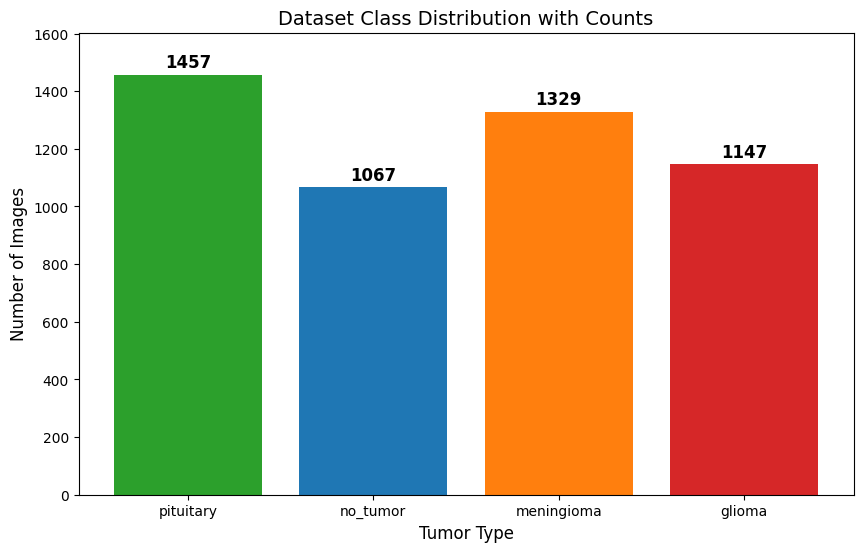

------------------------------
Tumor Category  | Count     
------------------------------
pituitary       | 1457      
no_tumor        | 1067      
meningioma      | 1329      
glioma          | 1147      
------------------------------
Total Training Images: 5000


In [ ]:
# Update this path based on your previous 'base_path'
class_train_dir = os.path.join(base_path, 'classification_task/train')
categories = os.listdir(class_train_dir)

# Count distribution
counts = {cat: len(os.listdir(os.path.join(class_train_dir, cat))) for cat in categories}

# Generate Bar Chart for Slide 1
plt.figure(figsize=(10, 6))
bars = plt.bar(counts.keys(), counts.values(), color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])

# --- NEW: Add numbers on top of each bar ---
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Dataset Class Distribution with Counts", fontsize=14)
plt.xlabel("Tumor Type", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.ylim(0, max(counts.values()) * 1.1) # Add space for labels
plt.show()

# --- NEW: Print a clean numerical summary ---
print("-" * 30)
print(f"{'Tumor Category':<15} | {'Count':<10}")
print("-" * 30)
for cat, count in counts.items():
    print(f"{cat:<15} | {count:<10}")
print("-" * 30)
print(f"Total Training Images: {sum(counts.values())}")

In [ ]:
#file name diagnosis
# Check classification filenames
sample_class_dir = os.path.join(base_path, 'classification_task/train/glioma')
if os.path.exists(sample_class_dir):
    print("Class images (Glioma):", os.listdir(sample_class_dir)[:5])

# Check segmentation filenames
sample_seg_dir = os.path.join(base_path, 'segmentation_task/train')
if os.path.exists(sample_seg_dir):
    print("Segmentation files:", os.listdir(sample_seg_dir)[:5])

Class images (Glioma): ['brisc2025_train_00160_gl_ax_t1.jpg', 'brisc2025_train_00395_gl_co_t1.jpg', 'brisc2025_train_00748_gl_co_t1.jpg', 'brisc2025_train_00960_gl_sa_t1.jpg', 'brisc2025_train_01078_gl_sa_t1.jpg']
Segmentation files: ['images', 'masks']


In [ ]:
def get_data_paths_final(base_path, task_type='train'):
    img_list, mask_list, label_list = [], [], []

    # Map class names to integers for the classifier
    class_map = {'no_tumor': 0, 'meningioma': 1, 'pituitary': 2, 'glioma': 3}

    # Path to where all masks are stored for this split
    seg_mask_dir = os.path.join(base_path, 'segmentation_task', task_type, 'masks')

    for cls_name, cls_idx in class_map.items():
        cls_folder = os.path.join(base_path, 'classification_task', task_type, cls_name)
        if not os.path.exists(cls_folder):
            continue

        # Get image filenames
        images = sorted([f for f in os.listdir(cls_folder) if f.endswith('.jpg')])

        for img_name in images:
            img_path = os.path.join(cls_folder, img_name)

            # Find matching mask by converting extension
            mask_name = img_name.replace('.jpg', '.png')
            mask_path = os.path.join(seg_mask_dir, mask_name)

            # Only add if the mask exists to ensure perfect alignment
            if os.path.exists(mask_path):
                img_list.append(img_path)
                mask_list.append(mask_path)
                label_list.append(cls_idx)
            elif cls_name == 'no_tumor':
                # no_tumor scans have no mask file -> keep them, use an empty mask
                img_list.append(img_path)
                mask_list.append(None)
                label_list.append(cls_idx)

    return img_list, mask_list, label_list

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Run the alignment for the raw training and test data
raw_train_imgs, raw_train_masks, raw_train_labels = get_data_paths_final(base_path, 'train')
test_imgs, test_masks, test_labels = get_data_paths_final(base_path, 'test')

# 2. Perform the 80/20 Aligned Split
train_imgs, val_imgs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    raw_train_imgs,
    raw_train_masks,
    raw_train_labels,
    test_size=0.20,
    random_state=42,
    stratify=raw_train_labels
)

print(f"Final Data Split (80/20):")
print(f"--- Training Samples:   {len(train_imgs)}")
print(f"--- Validation Samples: {len(val_imgs)}")
print(f"--- Testing Samples:    {len(test_imgs)}")
from collections import Counter
print("Train class counts:", sorted(Counter(train_labels).items()))
print("Test class counts: ", sorted(Counter(test_labels).items()))

Final Data Split (80/20):
--- Training Samples:   4000
--- Validation Samples: 1000
--- Testing Samples:    1000
Train class counts: [(0, 854), (1, 1063), (2, 1165), (3, 918)]
Test class counts:  [(0, 140), (1, 306), (2, 300), (3, 254)]


In [ ]:
# Preprocessing + (train-only) augmentation
def get_transforms(train=False):
    aug = [
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(p=0.3),
    ] if train else []
    return A.Compose([
        A.Resize(256, 256),
        *aug,
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2

# 1. Define the Dataset class
class BrainProjectDataset(Dataset):
    def __init__(self, image_paths, mask_paths, labels, transform=None):
        self.image_paths, self.mask_paths, self.labels, self.transform = image_paths, mask_paths, labels, transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.mask_paths[idx] is None:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)   # no_tumor -> empty mask
        else:
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
        mask = torch.from_numpy(mask).float().unsqueeze(0) if not torch.is_tensor(mask) else mask.float().unsqueeze(0)
        if mask.max() > 1.0: mask = mask / 255.0
        return image, mask, torch.tensor(self.labels[idx], dtype=torch.long)

# 2. Create the Loaders using your aligned lists
train_ds = BrainProjectDataset(train_imgs, train_masks, train_labels, transform=get_transforms(train=True))
val_ds = BrainProjectDataset(val_imgs, val_masks, val_labels, transform=get_transforms())
test_ds = BrainProjectDataset(test_imgs, test_masks, test_labels, transform=get_transforms())

# Necessity: Batch size 16 for GPU stability
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

print("DataLoaders defined. You can now run the visual verification.")

DataLoaders defined. You can now run the visual verification.


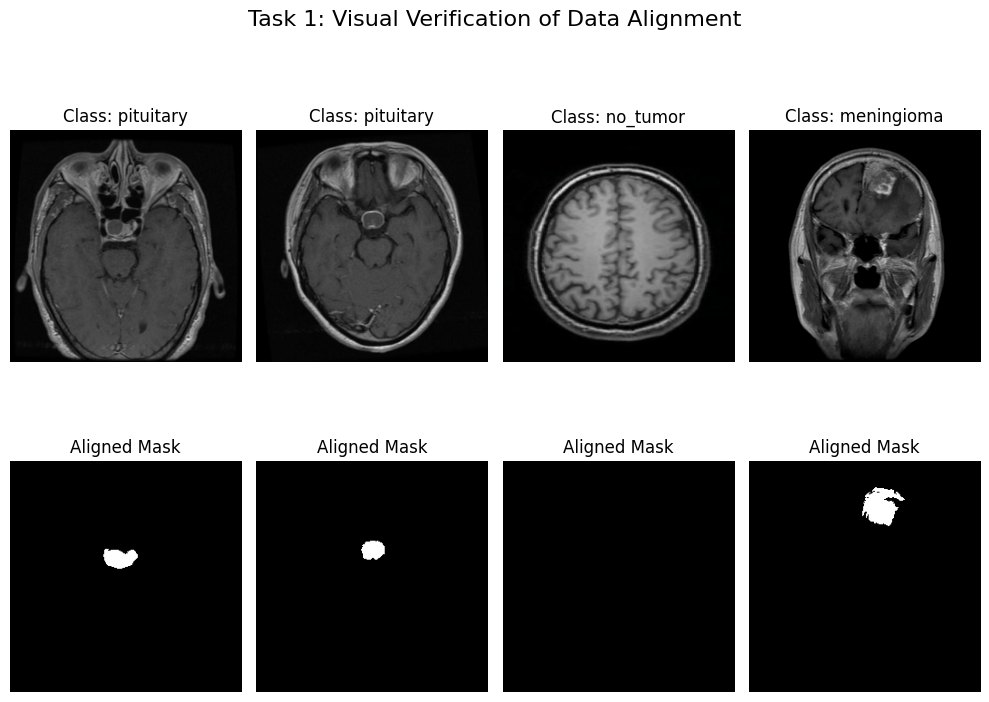

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pull one batch of data
images, masks, labels = next(iter(train_loader))

# 2. Define the class names based on your project requirements
class_names = ['no_tumor', 'meningioma', 'pituitary', 'glioma']

# 3. Create a visualization plot
plt.figure(figsize=(10, 8))

# ImageNet constants for un-normalization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(4): # Verify first 4 images in the batch
    # --- Top Row: MRI Images ---
    plt.subplot(2, 4, i + 1)

    # Move from [C, H, W] to [H, W, C] and move to CPU
    img = images[i].permute(1, 2, 0).cpu().numpy()

    # Reverse the normalization
    img = img * std + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Class: {class_names[labels[i]]}")
    plt.axis('off')

    # --- Bottom Row: Aligned Masks ---
    plt.subplot(2, 4, i + 5)
    # Squeeze the channel dimension [1, 256, 256] -> [256, 256]
    plt.imshow(masks[i].squeeze().cpu().numpy(), cmap='gray')
    plt.title("Aligned Mask")
    plt.axis('off')

plt.suptitle("Task 1: Visual Verification of Data Alignment", fontsize=16)
plt.tight_layout()
plt.show()

# **MODEL DESIGN**


# U-Net Architecture

In [ ]:
# import torch

# #Base Architecture
# import segmentation_models_pytorch as smp
# import torch.nn as nn

# class BaseUNetModel(nn.Module):
#     def __init__(self, num_classes=4):
#         super(BaseUNetModel, self).__init__()

#         # Base Architecture: Standard U-Net [cite: 37]
#         self.unet = smp.Unet(
#             encoder_name="resnet34",
#             encoder_weights="imagenet",
#             in_channels=3,
#             classes=1
#         )

#         # Classifier Head [cite: 38]
#         self.classifier = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),
#             nn.Flatten(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3), # Regularization parameter [cite: 12]
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         features = self.unet.encoder(x)

#         # FIX: Remove the asterisk (*) from features
#         decoder_output = self.unet.decoder(features)
#         mask_pred = self.unet.segmentation_head(decoder_output)

#         # Classification from encoder bottleneck [cite: 38]
#         class_pred = self.classifier(features[-1])

#         return mask_pred, class_pred

# # Re-initialize on T4 GPU
# model = BaseUNetModel(num_classes=4).to(device)
# # model = BaseUNetModel(num_classes=4).to(device)
# print("Base U-Net Model Fixed and Initialized.")

In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}, smp version: {smp.__version__}")

class BaseUNetModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        major, minor = (int(v) for v in smp.__version__.split(".")[:2])
        self.new_decoder_api = (major, minor) >= (0, 5)

    def forward(self, x):
        features = self.unet.encoder(x)

        if self.new_decoder_api:
            decoder_output = self.unet.decoder(features)    # smp >= 0.5
        else:
            decoder_output = self.unet.decoder(*features)   # smp < 0.5

        mask_pred = self.unet.segmentation_head(decoder_output)
        class_pred = self.classifier(features[-1])
        return mask_pred, class_pred

model = BaseUNetModel(num_classes=4).to(device)

# sanity check
x = torch.randn(2, 3, 256, 256).to(device)
mask, cls = model(x)
print(mask.shape, cls.shape)

Using device: cuda, smp version: 0.5.0


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

torch.Size([2, 1, 256, 256]) torch.Size([2, 4])


In [ ]:
import torch.optim as optim

# 1. Choose Optimizer: Adam is a standard 'Common Pattern' for U-Nets
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 2. Choose Scheduler: This satisfies the 'Hyperparameter Tuning' requirement
# It reduces learning rate if the Validation Loss doesn't improve for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# 3. Define Loss Functions for Joint Training
seg_criterion = smp.losses.DiceLoss(mode='binary') # For Segmentation
cls_criterion = nn.CrossEntropyLoss()              # For Classification

print("Optimizer, Scheduler, and Loss Functions initialized successfully.")

Optimizer, Scheduler, and Loss Functions initialized successfully.


In [ ]:
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm

#Configuration & Initialization
epochs = 15
best_val_loss = float('inf')
best_model_path = 'best_joint_unet_model.pth'

history = {
    'train_loss': [], 'train_acc': [], 'train_dice': [], 'train_auc': [],
    'val_loss': [], 'val_acc': [], 'val_dice': [], 'val_auc': []
}

for epoch in range(epochs):
    #TRAINING PHASE
    model.train()
    train_loss, train_correct, train_total, train_dice = 0.0, 0, 0, 0.0
    train_preds_all, train_labels_all = [], []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")
    for images, masks, labels in loop:
        images, masks, labels = images.to(device), masks.to(device), labels.to(device)

        optimizer.zero_grad()
        mask_preds, class_preds = model(images)

        # Joint Loss
        loss_seg = seg_criterion(mask_preds, masks)
        loss_cls = cls_criterion(class_preds, labels)
        total_loss = loss_seg + loss_cls

        total_loss.backward()
        optimizer.step()

        # Update Training Metrics
        train_loss += total_loss.item()
        _, predicted = torch.max(class_preds, 1)
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

        preds_mask = (torch.sigmoid(mask_preds) > 0.5).float()
        dice = (2. * (preds_mask * masks).sum()) / (preds_mask.sum() + masks.sum() + 1e-8)
        train_dice += dice.item()

        train_preds_all.append(F.softmax(class_preds, dim=1).detach().cpu().numpy())
        train_labels_all.append(labels.cpu().numpy())

    #VALIDATION PHASE
    model.eval()
    val_loss, val_correct, val_total, val_dice = 0.0, 0, 0, 0.0
    val_preds_all, val_labels_all = [], []

    with torch.no_grad():
        for images, masks, labels in val_loader:
            images, masks, labels = images.to(device), masks.to(device), labels.to(device)

            mask_preds, class_preds = model(images)
            v_loss = seg_criterion(mask_preds, masks) + cls_criterion(class_preds, labels)
            val_loss += v_loss.item()

            _, predicted = torch.max(class_preds, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

            preds_mask = (torch.sigmoid(mask_preds) > 0.5).float()
            v_dice = (2. * (preds_mask * masks).sum()) / (preds_mask.sum() + masks.sum() + 1e-8)
            val_dice += v_dice.item()

            val_preds_all.append(F.softmax(class_preds, dim=1).cpu().numpy())
            val_labels_all.append(labels.cpu().numpy())

    # --- EPOCH CALCULATIONS (FIXED AUC) ---
    train_auc = roc_auc_score(np.concatenate(train_labels_all), np.concatenate(train_preds_all), multi_class='ovr', labels=[0,1,2,3])
    val_auc = roc_auc_score(np.concatenate(val_labels_all), np.concatenate(val_preds_all), multi_class='ovr', labels=[0,1,2,3])

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss) # Task 3: Hyperparameter Optimization

    # --- SAVE BEST MODEL (FIXED TYPO) ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Best Model Saved (Val Loss: {avg_val_loss:.4f})")

    # Logging History for Task 4
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_correct / train_total)
    history['train_dice'].append(train_dice / len(train_loader))
    history['train_auc'].append(train_auc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_correct/val_total)
    history['val_auc'].append(val_auc)
    history['val_dice'].append(val_dice/len(val_loader))

    print(f"Epoch {epoch+1}: Val Acc: {val_correct/val_total:.4f} | Val AUC: {val_auc:.4f} | Val Dice: {val_dice/len(val_loader):.4f}\n")

# Reload best model at the end
model.load_state_dict(torch.load(best_model_path))
print(" Training Complete. Best weights restored for evaluation.")

Epoch 1/15 [TRAIN]: 100%|██████████| 250/250 [02:08<00:00,  1.95it/s]


--> Best Model Saved (Val Loss: 1.0259)
Epoch 1: Val Acc: 0.9530 | Val AUC: 0.9975 | Val Dice: 0.3160



Epoch 2/15 [TRAIN]: 100%|██████████| 250/250 [01:27<00:00,  2.86it/s]


--> Best Model Saved (Val Loss: 0.7285)
Epoch 2: Val Acc: 0.9600 | Val AUC: 0.9992 | Val Dice: 0.7365



Epoch 3/15 [TRAIN]: 100%|██████████| 250/250 [01:31<00:00,  2.75it/s]


...

Epoch 13: Val Acc: 0.9840 | Val AUC: 0.9988 | Val Dice: 0.8594



Epoch 14/15 [TRAIN]: 100%|██████████| 250/250 [01:30<00:00,  2.76it/s]


Epoch 14: Val Acc: 0.9860 | Val AUC: 0.9992 | Val Dice: 0.8547



Epoch 15/15 [TRAIN]: 100%|██████████| 250/250 [01:32<00:00,  2.71it/s]


Epoch 15: Val Acc: 0.9900 | Val AUC: 0.9990 | Val Dice: 0.8693

 Training Complete. Best weights restored for evaluation.


In [ ]:
train_acc = train_correct / train_total
print(f" Train Accuracy: {train_acc:.4f}")

 Train Accuracy: 0.9935


Running Final Evaluation on Test Set...
-----------------------------------
Final Test Accuracy:   99.00%
Final Test Dice Score: 75.31%
-----------------------------------

--- Final Classification Report ---
              precision    recall  f1-score   support

    no_tumor       0.99      1.00      1.00       140
  meningioma       0.98      0.99      0.99       306
   pituitary       0.99      0.99      0.99       300
      glioma       0.99      0.99      0.99       254

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



<Figure size 800x600 with 0 Axes>

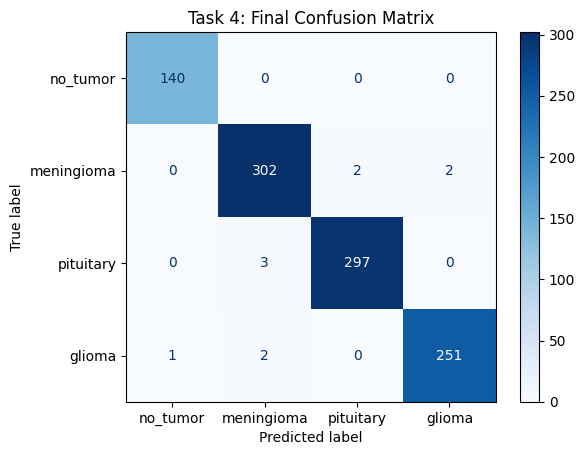

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Set model to evaluation mode
model.eval()

all_labels = []
all_preds = []
test_dice_scores = [] # List to store Dice per batch

print("Running Final Evaluation on Test Set...")
with torch.no_grad():
    # REQUIRED: Add 'masks' to the loop to calculate Dice
    for images, masks, labels in test_loader:
        images, masks = images.to(device), masks.to(device)

        # Get both outputs from your Joint Model
        mask_preds, class_logits = model(images)

        # --- 1. Segmentation Metric (Dice) ---
        # Convert logits to binary mask using sigmoid and threshold
        preds_mask = (torch.sigmoid(mask_preds) > 0.5).float()

        # Intersection over Sum formula
        intersection = (preds_mask * masks).sum()
        dice = (2. * intersection) / (preds_mask.sum() + masks.sum() + 1e-8)
        test_dice_scores.append(dice.item())

        # --- 2. Classification Metric ---
        preds = torch.argmax(class_logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)
final_dice = np.mean(test_dice_scores) # Calculate average Dice

# 2. Display Combined Results
test_acc = accuracy_score(y_true, y_pred)
print("-" * 35)
print(f"Final Test Accuracy:   {test_acc * 100:.2f}%")
print(f"Final Test Dice Score: {final_dice * 100:.2f}%") # Now it will show
print("-" * 35)

# 3. Report and Confusion Matrix
class_indices = [0, 1, 2, 3]
target_names = ['no_tumor', 'meningioma', 'pituitary', 'glioma']

print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, labels=class_indices, target_names=target_names, zero_division=0))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=class_indices)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Task 4: Final Confusion Matrix")
plt.show()

# Taking Input image as input and outputs

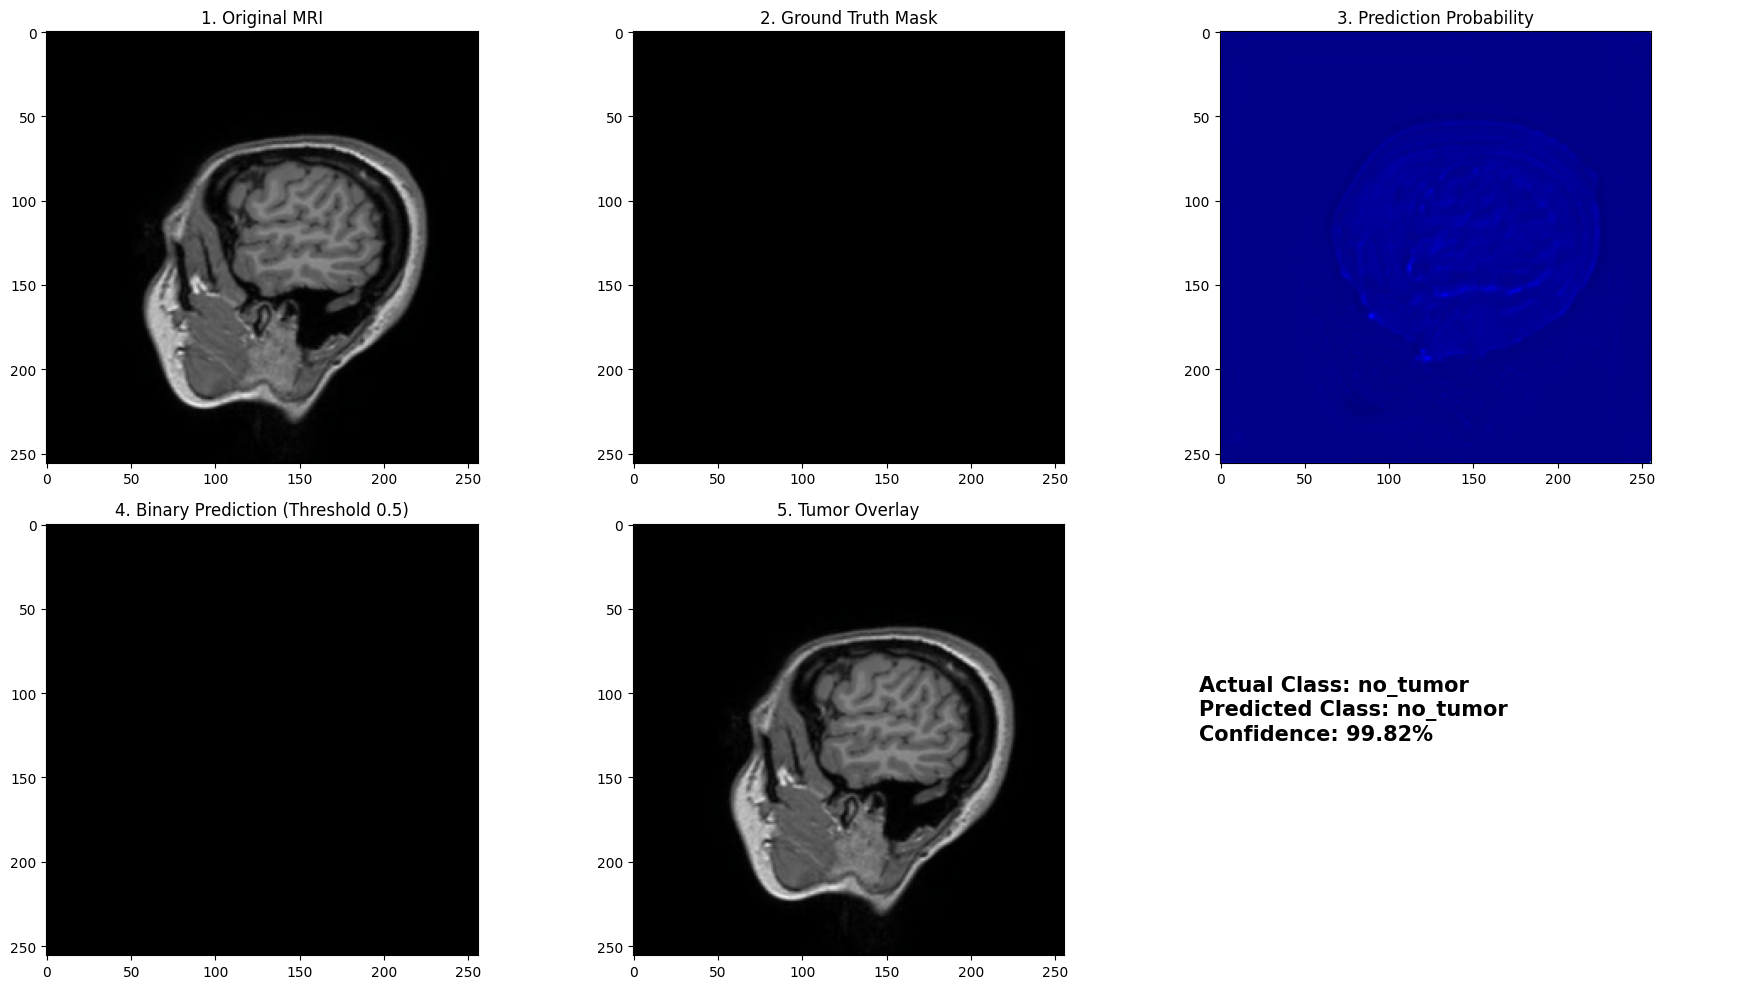

In [ ]:
import torch.nn.functional as F
                                                    #best model er upor test run kore accuracy
def final_demonstration(model, dataset, idx=None):  #per classwise accuracy rate test
    model.eval()
    if idx is None:
        idx = np.random.randint(0, len(dataset))

    image, mask, label = dataset[idx]
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        mask_pred, class_pred = model(image_input)

        # Process Segmentation
        prob_mask = torch.sigmoid(mask_pred).squeeze().cpu().numpy()
        binary_mask = prob_mask > 0.5

        # Process Classification
        probs = F.softmax(class_pred, dim=1)
        conf, pred_idx = torch.max(probs, dim=1)

    # Un-normalize for display
    img_np = image.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)

    # 6-Panel Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Original
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("1. Original MRI")

    # 2. Ground Truth Mask
    axes[0, 1].imshow(mask.squeeze().cpu().numpy(), cmap='gray')
    axes[0, 1].set_title("2. Ground Truth Mask")

    # 3. Predicted Mask (Probability Heatmap)
    axes[0, 2].imshow(prob_mask, cmap='jet')
    axes[0, 2].set_title("3. Prediction Probability")

    # 4. Binary Prediction
    axes[1, 0].imshow(binary_mask, cmap='gray')
    axes[1, 0].set_title("4. Binary Prediction (Threshold 0.5)")

    # 5. Overlay
    overlay = img_np.copy()
    overlay[binary_mask] = overlay[binary_mask] * 0.5 + np.array([1, 0, 0]) * 0.5 # Red tint for tumor
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title("5. Tumor Overlay")

    # 6. Final Result Text
    axes[1, 2].axis('off')
    result_text = (f"Actual Class: {class_names[label]}\n"
                   f"Predicted Class: {class_names[pred_idx.item()]}\n"
                   f"Confidence: {conf.item():.2%}")
    axes[1, 2].text(0.1, 0.5, result_text, fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Call this for a random test image
final_demonstration(model, test_ds)

# Updated Architecture (Attention U-Net)

In [ ]:

import segmentation_models_pytorch as smp
import torch.nn as nn

class AttentionUNetOnly(nn.Module):
    def __init__(self):
        super(AttentionUNetOnly, self).__init__()

        # Architecture: U-Net with scSE attention (not the attention-gate Attention U-Net) for Segmentation ONLY
        # 'scse' adds the Spatial and Channel Squeeze & Excitation (Attention)
        self.unet = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=3,
            classes=1, # Binary segmentation output
            decoder_attention_type='scse'
        )

    def forward(self, x):
        # Only returns the mask prediction
        mask_pred = self.unet(x)
        return mask_pred

# Initialize for T4 GPU
model_attn_seg = AttentionUNetOnly().to(device)
print("Attention U-Net (Segmentation Only) Initialized.")

Attention U-Net (Segmentation Only) Initialized.


In [ ]:
import torch.optim as optim

# 1. Initialize the Attention Model Optimizer
# We use a learning rate of 1e-4 for stable convergence with Attention gates
optimizer_attn = optim.Adam(model_attn_seg.parameters(), lr=1e-4)

# 2. Setup Scheduler for Hyperparameter Tuning
scheduler_attn = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_attn, mode='min', factor=0.1, patience=2
)

# 3. Define Segmentation Loss
seg_criterion = smp.losses.DiceLoss(mode='binary')

print("Attention Optimizer and Scheduler initialized.")

Attention Optimizer and Scheduler initialized.


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

# Configuration for Model Selection
best_val_dice = 0.0
best_attn_model_path = 'best_attention_unet.pth'
epochs = 10

history_attn = {
    'train_loss': [], 'train_dice': [],
    'val_loss': [], 'val_dice': []
}

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model_attn_seg.train()
    train_loss, train_dice = 0.0, 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")
    for images, masks, _ in loop:
        images, masks = images.to(device), masks.to(device)

        optimizer_attn.zero_grad()
        mask_pred = model_attn_seg(images)

        # Loss and Backpropagation
        loss = seg_criterion(mask_pred, masks)
        loss.backward()
        optimizer_attn.step()

        train_loss += loss.item()

        # Calculate Dice Score
        preds = (torch.sigmoid(mask_pred) > 0.5).float()
        dice = (2. * (preds * masks).sum()) / (preds.sum() + masks.sum() + 1e-8)
        train_dice += dice.item()

    # --- VALIDATION PHASE ---
    model_attn_seg.eval()
    val_loss, val_dice = 0.0, 0.0

    with torch.no_grad():
        for images, masks, _ in val_loader:
            images, masks = images.to(device), masks.to(device)

            mask_pred = model_attn_seg(images)
            v_loss = seg_criterion(mask_pred, masks)

            val_loss += v_loss.item()
            preds = (torch.sigmoid(mask_pred) > 0.5).float()
            v_dice = (2. * (preds * masks).sum()) / (preds.sum() + masks.sum() + 1e-8)
            val_dice += v_dice.item()

    # Metrics Averaging
    avg_train_loss = train_loss / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    # Learning Rate Optimization
    scheduler_attn.step(avg_val_loss)

    # --- SELECT BEST MODEL (Based on Validation Dice) ---
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model_attn_seg.state_dict(), best_attn_model_path)
        print(f"--> Best Attention Model Saved (Val Dice: {avg_val_dice:.4f})")

    # Logging
    history_attn['train_loss'].append(avg_train_loss)
    history_attn['train_dice'].append(avg_train_dice)
    history_attn['val_loss'].append(avg_val_loss)
    history_attn['val_dice'].append(avg_val_dice)

    print(f"Epoch {epoch+1}: Train Dice: {avg_train_dice:.4f} | Val Dice: {avg_val_dice:.4f} | LR: {optimizer_attn.param_groups[0]['lr']:.6f}\n")

# Restore Best Weights
model_attn_seg.load_state_dict(torch.load(best_attn_model_path))
print("Training Complete. Best Attention Weights Restored.")

Epoch 1/10 [TRAIN]: 100%|██████████| 250/250 [01:46<00:00,  2.35it/s]


--> Best Attention Model Saved (Val Dice: 0.6751)
Epoch 1: Train Dice: 0.3131 | Val Dice: 0.6751 | LR: 0.000100



Epoch 2/10 [TRAIN]: 100%|██████████| 250/250 [01:46<00:00,  2.36it/s]


--> Best Attention Model Saved (Val Dice: 0.8102)
Epoch 2: Train Dice: 0.7494 | Val Dice: 0.8102 | LR: 0.000100



Epoch 3/10 [TRAIN]: 100%|██████████| 250/250 [01:45<00:00,  2.37it/s]


...

--> Best Attention Model Saved (Val Dice: 0.8487)
Epoch 8: Train Dice: 0.8652 | Val Dice: 0.8487 | LR: 0.000100



Epoch 9/10 [TRAIN]: 100%|██████████| 250/250 [01:43<00:00,  2.41it/s]


--> Best Attention Model Saved (Val Dice: 0.8569)
Epoch 9: Train Dice: 0.8668 | Val Dice: 0.8569 | LR: 0.000100



Epoch 10/10 [TRAIN]: 100%|██████████| 250/250 [01:43<00:00,  2.42it/s]


Epoch 10: Train Dice: 0.8749 | Val Dice: 0.8540 | LR: 0.000100

Training Complete. Best Attention Weights Restored.


In [ ]:
import torch
import numpy as np

# 1. Set model to evaluation mode
model_attn_seg.eval()

test_dice_scores = []
test_iou_scores = []

print("Running Evaluation on Test Set...")

with torch.no_grad():
    for images, masks, _ in test_loader:
        images, masks = images.to(device), masks.to(device)

        # Forward pass
        output_mask = model_attn_seg(images)

        # Apply threshold to get binary mask
        preds = (torch.sigmoid(output_mask) > 0.5).float()

        # Calculate Dice Score
        intersection = (preds * masks).sum()
        dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-8)
        test_dice_scores.append(dice.item())

        # Calculate IoU (Intersection over Union)
        union = preds.sum() + masks.sum() - intersection
        iou = (intersection + 1e-8) / (union + 1e-8)
        test_iou_scores.append(iou.item())

# 2. Final Results Summary
final_test_dice = np.mean(test_dice_scores)
final_test_iou = np.mean(test_iou_scores)


print(f"Final Test Dice Score: {final_test_dice:.4f}")
print(f"Final Test mIoU:       {final_test_iou:.4f}")


Running Evaluation on Test Set...
Final Test Dice Score: 0.7585
Final Test mIoU:       0.8062


# Performance Comparison

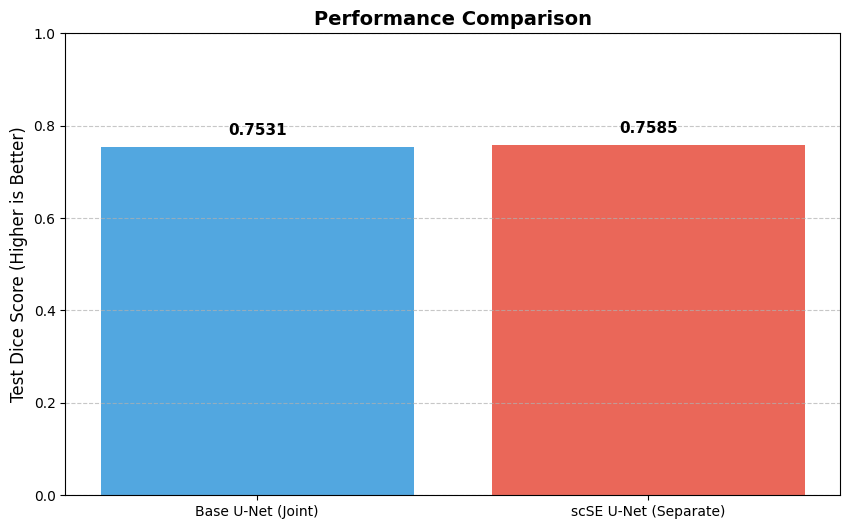

Dice difference (scSE U-Net - Base U-Net): +0.0054
Single run / single seed, and the two setups differ (joint vs seg-only training),
so a gap this small should be treated as inconclusive.


In [ ]:
import matplotlib.pyplot as plt

# 1. Final Test Data from your evaluation runs
models = ['Base U-Net (Joint)', 'scSE U-Net (Separate)']
# Using the final test scores you just calculated
dice_scores = [final_dice, final_test_dice]

# 2. Visualization
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c'] # Professional blue and red
bars = plt.bar(models, dice_scores, color=colors, alpha=0.85)

plt.ylim(0, 1.0)
plt.ylabel('Test Dice Score (Higher is Better)', fontsize=12)
plt.title('Performance Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f'{yval:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.show()

# 3. Neutral analysis
diff = final_test_dice - final_dice
print(f"Dice difference (scSE U-Net - Base U-Net): {diff:+.4f}")
print("Single run / single seed, and the two setups differ (joint vs seg-only training),")
print("so a gap this small should be treated as inconclusive.")


Gathering final test results...
----------------------------------------
Final Test Classification Accuracy: 0.9900
----------------------------------------


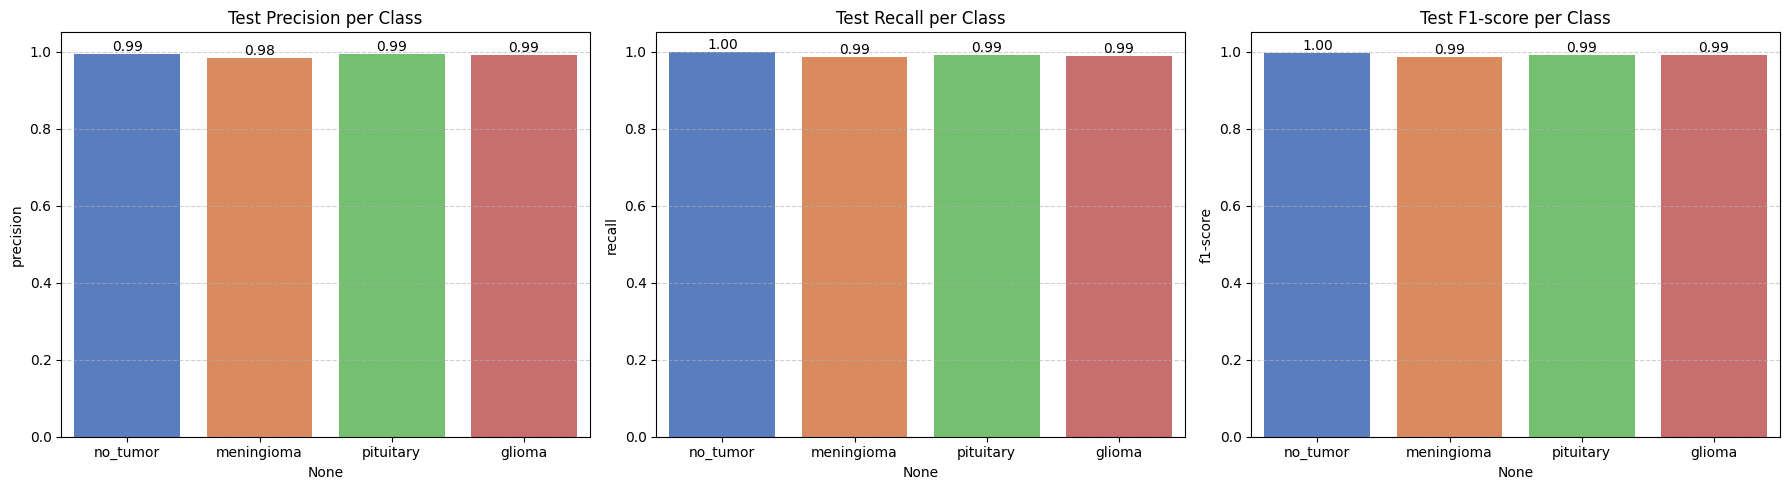

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
import torch
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Collect Predictions & Calculate Dice
model.eval()
y_true, y_pred = [], []
test_dice_scores = []

print("Gathering final test results...")
with torch.no_grad():
    for images, masks, labels in test_loader:
        images, masks = images.to(device), masks.to(device)

        # Get Joint model outputs
        mask_preds, class_logits = model(images)

        # --- Segmentation Metric (Dice) ---
        preds_mask = (torch.sigmoid(mask_preds) > 0.5).float()
        intersection = (preds_mask * masks).sum()
        dice = (2. * intersection) / (preds_mask.sum() + masks.sum() + 1e-8)
        test_dice_scores.append(dice.item())

        # --- Classification Metrics ---
        preds_class = torch.argmax(class_logits, dim=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_class.cpu().numpy())

# 2. Programmatically Calculate Metrics
unique_labels = np.unique(y_true)
class_names = ['no_tumor', 'meningioma', 'pituitary', 'glioma']
existing_class_names = [class_names[i] for i in unique_labels]

overall_acc = accuracy_score(y_true, y_pred)
avg_test_dice = np.mean(test_dice_scores)
report_dict = classification_report(y_true, y_pred, labels=unique_labels,
                                    target_names=existing_class_names, output_dict=True)

# Format for plotting
df_metrics = pd.DataFrame(report_dict).transpose()
df_classes = df_metrics.loc[existing_class_names]

# 3. Final Summary Output
print("-" * 40)
print(f"Final Test Classification Accuracy: {overall_acc:.4f}")
#print(f"Final Test Segmentation Dice Score: {avg_test_dice:.4f}")
print("-" * 40)

# 4. Generate Metric Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['precision', 'recall', 'f1-score']

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=df_classes.index, y=df_classes[metric], ax=axes[i],
                hue=df_classes.index, palette='muted', legend=False)

    axes[i].set_title(f'Test {metric.capitalize()} per Class')
    axes[i].set_ylim(0, 1.05)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# Segmentation Performance Comparison: Joint vs. Separate Training

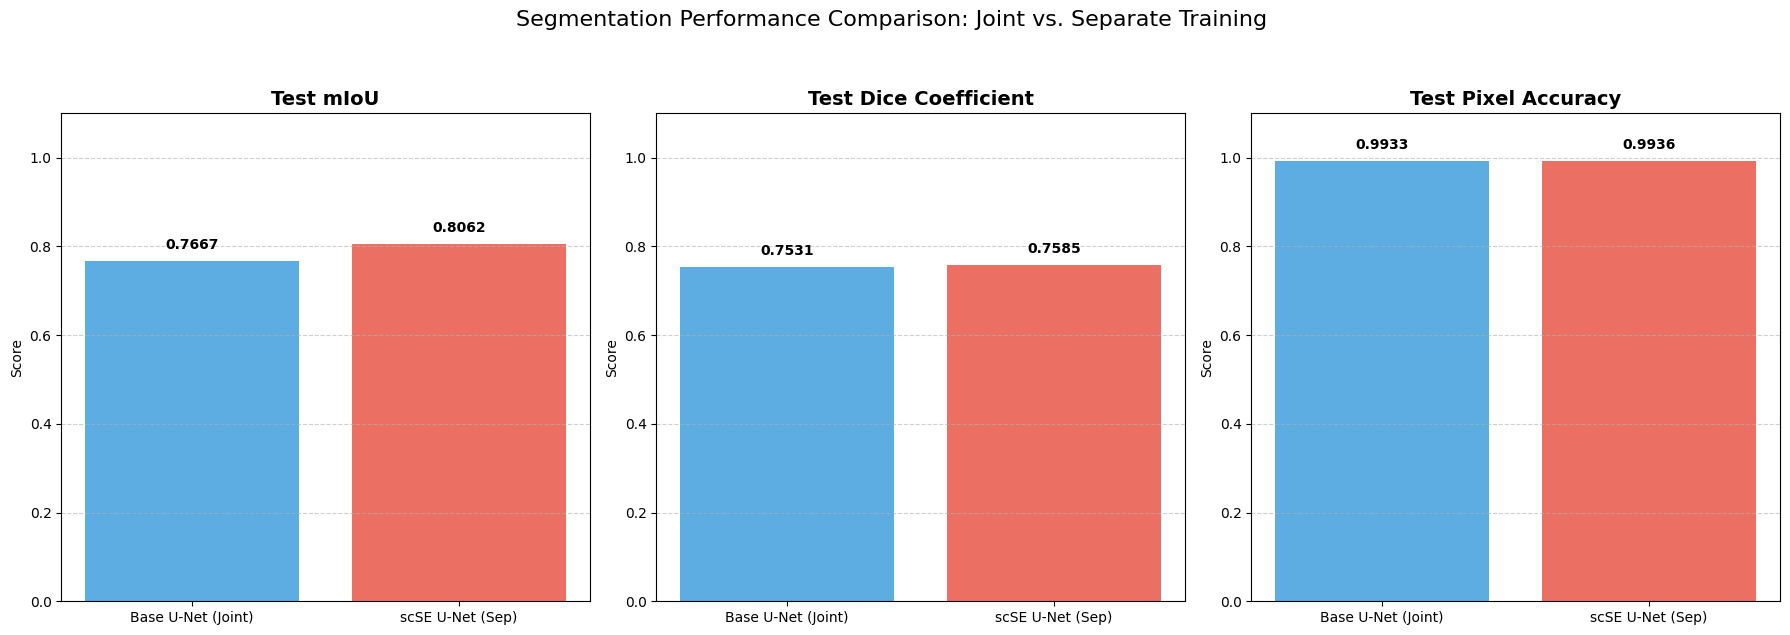

--- Final Comparison Analysis ---
1. Dice: +0.0054 (scSE U-Net minus Base U-Net)
2. mIoU: +0.0395
3. Pixel accuracy: +0.0002


In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_segmentation_metrics(model, loader, is_joint=True):
    model.eval()
    ious, dices, accs = [], [], []

    with torch.no_grad():
        for images, masks, _ in loader:
            images, masks = images.to(device), masks.to(device)

            # 1. Get prediction from correct model head
            output = model(images)
            mask_pred = output[0] if is_joint else output # Joint has (mask, class), Separate has mask

            # 2. Thresholding to binary mask
            preds = (torch.sigmoid(mask_pred) > 0.5).float()

            # 3. Dice Coefficient
            intersection = (preds * masks).sum()
            dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-8)

            # 4. Intersection over Union (IoU)
            union = (preds + masks).clamp(0, 1).sum()
            iou = (intersection + 1e-8) / (union + 1e-8)

            # 5. Pixel Accuracy (Correct vs Total Pixels)
            correct_pixels = (preds == masks).sum()
            pixel_acc = correct_pixels / masks.numel()

            ious.append(iou.item())
            dices.append(dice.item())
            accs.append(pixel_acc.item())

    return np.mean(ious), np.mean(dices), np.mean(accs)

# --- Execute Metrics Calculation ---
base_miou, base_dice, base_p_acc = get_segmentation_metrics(model, test_loader, is_joint=True)
attn_miou, attn_dice, attn_p_acc = get_segmentation_metrics(model_attn_seg, test_loader, is_joint=False)

# --- Visualization Setup ---
metrics = ['mIoU', 'Dice Coefficient', 'Pixel Accuracy']
base_scores = [base_miou, base_dice, base_p_acc]
attn_scores = [attn_miou, attn_dice, attn_p_acc]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#3498db', '#e74c3c']
model_labels = ['Base U-Net (Joint)', 'scSE U-Net (Sep)']

for i, metric in enumerate(metrics):
    scores = [base_scores[i], attn_scores[i]]
    bars = axes[i].bar(model_labels, scores, color=colors, alpha=0.8)

    axes[i].set_title(f'Test {metric}', fontsize=14, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.02,
                     f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Segmentation Performance Comparison: Joint vs. Separate Training ', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# --- Comparative analysis (numbers decide the wording) ---
print("--- Final Comparison Analysis ---")
print(f"1. Dice: {attn_dice - base_dice:+.4f} (scSE U-Net minus Base U-Net)")
print(f"2. mIoU: {attn_miou - base_miou:+.4f}")
print(f"3. Pixel accuracy: {attn_p_acc - base_p_acc:+.4f}")



# TRAINING/VALIDATION LOSS & ACCURACY CURVES

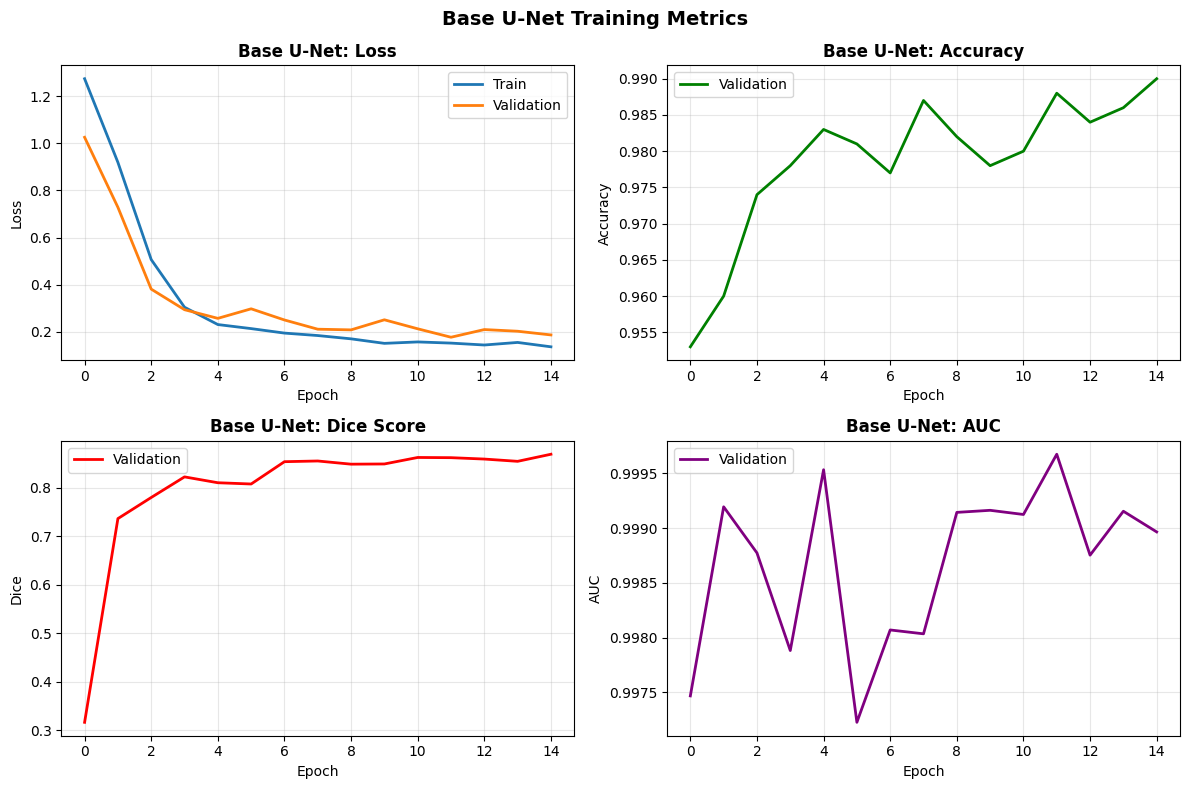

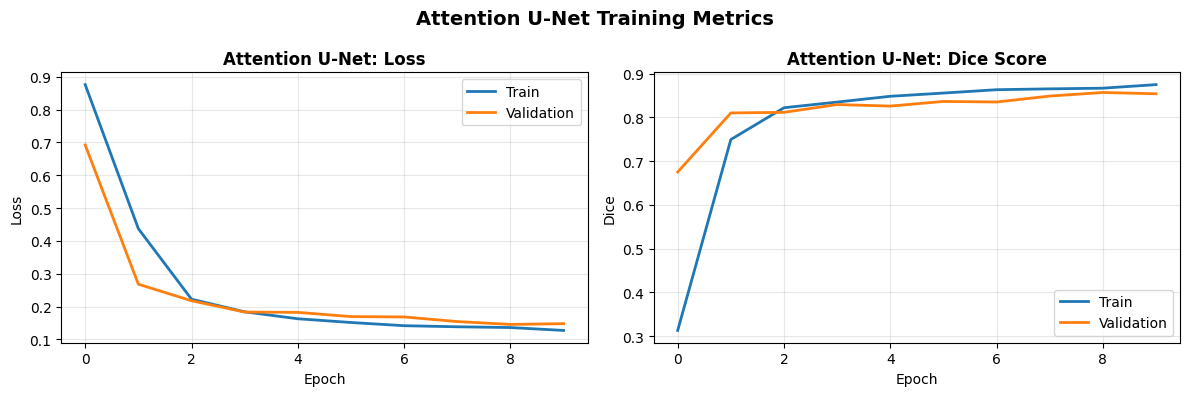

In [32]:


import matplotlib.pyplot as plt

# BASE U-NET CURVES
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Loss
axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('Base U-Net: Loss', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(history['val_acc'], label='Validation', linewidth=2, color='green')
axes[0, 1].set_title('Base U-Net: Accuracy', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Dice
axes[1, 0].plot(history['val_dice'], label='Validation', linewidth=2, color='red')
axes[1, 0].set_title('Base U-Net: Dice Score', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Dice')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. AUC
axes[1, 1].plot(history['val_auc'], label='Validation', linewidth=2, color='purple')
axes[1, 1].set_title('Base U-Net: AUC', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Base U-Net Training Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ATTENTION U-NET CURVES
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Loss
axes[0].plot(history_attn['train_loss'], label='Train', linewidth=2)
axes[0].plot(history_attn['val_loss'], label='Validation', linewidth=2)
axes[0].set_title('Attention U-Net: Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Dice
axes[1].plot(history_attn['train_dice'], label='Train', linewidth=2)
axes[1].plot(history_attn['val_dice'], label='Validation', linewidth=2)
axes[1].set_title('Attention U-Net: Dice Score', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Attention U-Net Training Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# BAD PREDICTIONS FOR BOTH MODELS

Finding incorrect predictions for BASE U-NET...


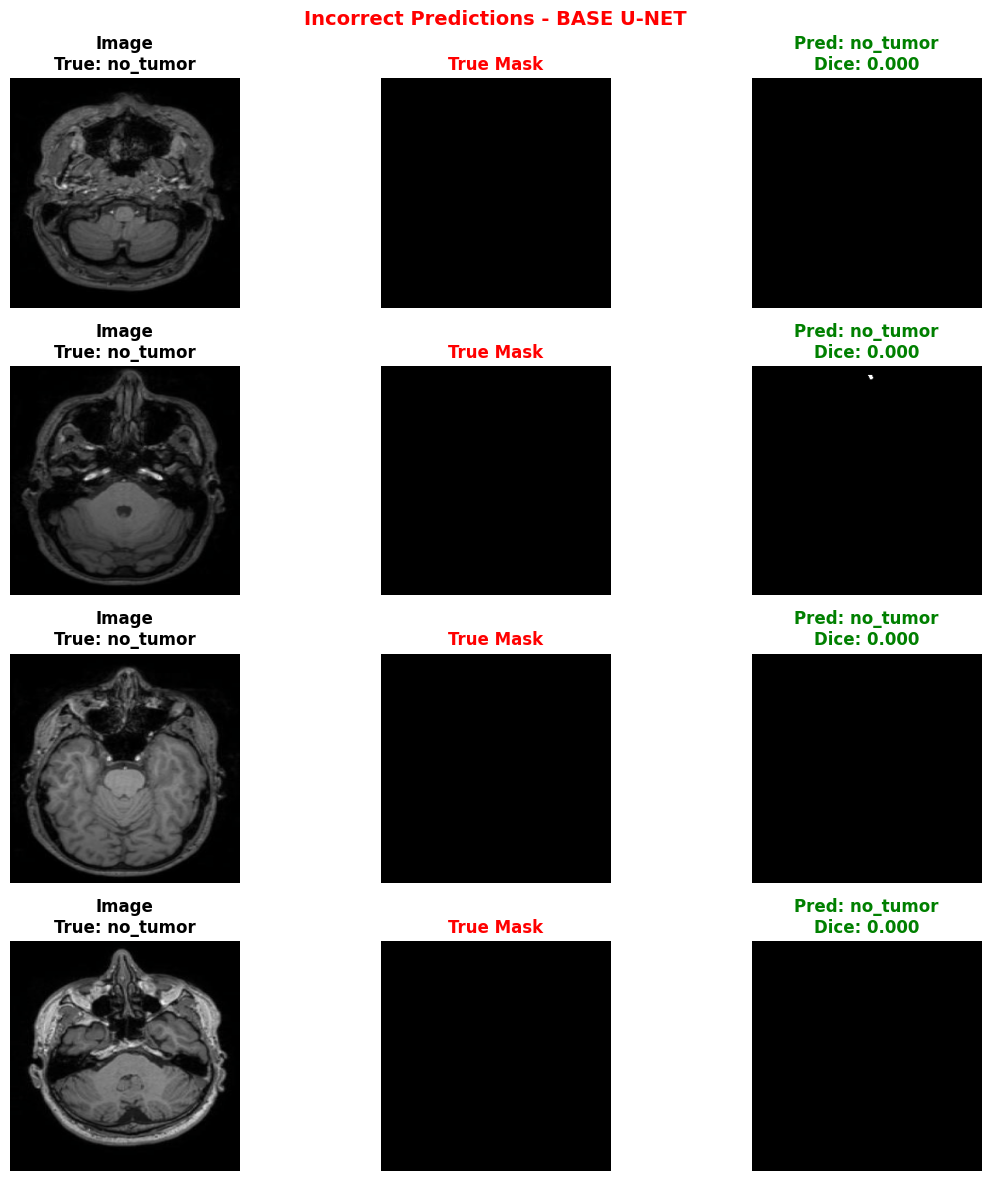

 Found 280 incorrect predictions for Base U-Net

Finding incorrect predictions for ATTENTION U-NET...


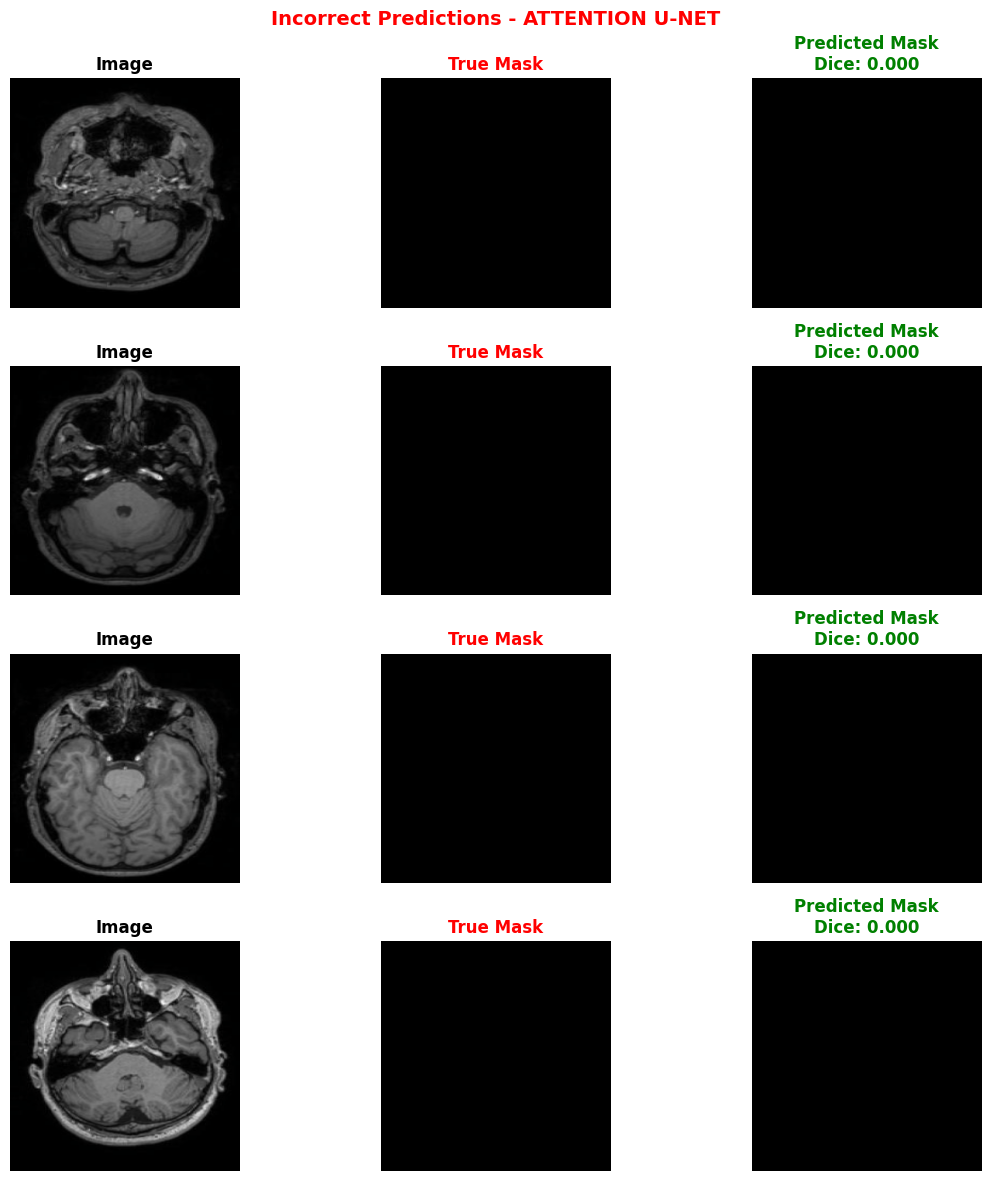

Found 267 incorrect predictions for Attention U-Net

SUMMARY
Base U-Net incorrect predictions:      280
Attention U-Net incorrect predictions: 267


In [33]:
import torch
import matplotlib.pyplot as plt
import numpy as np

class_names = ['no_tumor', 'meningioma', 'pituitary', 'glioma']
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# ===== BASE U-NET BAD PREDICTIONS =====
print("=" * 70)
print("Finding incorrect predictions for BASE U-NET...")
print("=" * 70)

model.eval()
incorrect_base = []

with torch.no_grad():
    for images, masks, labels in test_loader:
        images, masks, labels = images.to(device), masks.to(device), labels.to(device)
        mask_preds, class_preds = model(images)

        _, predicted = torch.max(class_preds, 1)
        pred_masks = (torch.sigmoid(mask_preds) > 0.5).float()

        for i in range(images.size(0)):
            # Check if wrong classification OR poor segmentation
            wrong_class = (predicted[i] != labels[i])

            intersection = (pred_masks[i] * masks[i]).sum()
            dice = (2. * intersection) / (pred_masks[i].sum() + masks[i].sum() + 1e-8)
            poor_seg = dice < 0.7

            if wrong_class or poor_seg:
                incorrect_base.append({
                    'image': images[i].cpu(),
                    'true_mask': masks[i].cpu(),
                    'pred_mask': pred_masks[i].cpu(),
                    'true_label': labels[i].item(),
                    'pred_label': predicted[i].item(),
                    'dice': dice.item()
                })


n_bad_base = len(incorrect_base)
incorrect_base = sorted(incorrect_base, key=lambda e: e['dice'])[:4]   # show the 4 worst

# Visualize Base U-Net
fig, axes = plt.subplots(len(incorrect_base), 3, figsize=(12, len(incorrect_base) * 3))
if len(incorrect_base) == 1:
    axes = axes.reshape(1, -1)

for idx, ex in enumerate(incorrect_base):
    # Denormalize
    img = ex['image'].permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)

    # Original
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Image\nTrue: {class_names[ex['true_label']]}", fontweight='bold')
    axes[idx, 0].axis('off')

    # Ground Truth
    axes[idx, 1].imshow(ex['true_mask'].squeeze(), cmap='gray')
    axes[idx, 1].set_title("True Mask", fontweight='bold', color='red')
    axes[idx, 1].axis('off')

    # Prediction
    axes[idx, 2].imshow(ex['pred_mask'].squeeze(), cmap='gray')
    axes[idx, 2].set_title(f"Pred: {class_names[ex['pred_label']]}\nDice: {ex['dice']:.3f}",
                          fontweight='bold', color='green')
    axes[idx, 2].axis('off')

plt.suptitle('Incorrect Predictions - BASE U-NET', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

print(f" Found {n_bad_base} incorrect predictions for Base U-Net\n")


# ===== ATTENTION U-NET BAD PREDICTIONS =====
print("=" * 70)
print("Finding incorrect predictions for ATTENTION U-NET...")
print("=" * 70)

model_attn_seg.eval()
incorrect_attn = []

with torch.no_grad():
    for images, masks, labels in test_loader:
        images, masks = images.to(device), masks.to(device)
        mask_preds = model_attn_seg(images)

        pred_masks = (torch.sigmoid(mask_preds) > 0.5).float()

        for i in range(images.size(0)):
            # Check poor segmentation
            intersection = (pred_masks[i] * masks[i]).sum()
            dice = (2. * intersection) / (pred_masks[i].sum() + masks[i].sum() + 1e-8)
            poor_seg = dice < 0.7

            if poor_seg:
                incorrect_attn.append({
                    'image': images[i].cpu(),
                    'true_mask': masks[i].cpu(),
                    'pred_mask': pred_masks[i].cpu(),
                    'dice': dice.item()
                })


n_bad_attn = len(incorrect_attn)
incorrect_attn = sorted(incorrect_attn, key=lambda e: e['dice'])[:4]   # show the 4 worst

# Visualize Attention U-Net
fig, axes = plt.subplots(len(incorrect_attn), 3, figsize=(12, len(incorrect_attn) * 3))
if len(incorrect_attn) == 1:
    axes = axes.reshape(1, -1)

for idx, ex in enumerate(incorrect_attn):
    # Denormalize
    img = ex['image'].permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)

    # Original
    axes[idx, 0].imshow(img)
    axes[idx, 0].set_title(f"Image", fontweight='bold')
    axes[idx, 0].axis('off')

    # Ground Truth
    axes[idx, 1].imshow(ex['true_mask'].squeeze(), cmap='gray')
    axes[idx, 1].set_title("True Mask", fontweight='bold', color='red')
    axes[idx, 1].axis('off')

    # Prediction
    axes[idx, 2].imshow(ex['pred_mask'].squeeze(), cmap='gray')
    axes[idx, 2].set_title(f"Predicted Mask\nDice: {ex['dice']:.3f}",
                          fontweight='bold', color='green')
    axes[idx, 2].axis('off')

plt.suptitle('Incorrect Predictions - ATTENTION U-NET', fontsize=14, fontweight='bold', color='red')
plt.tight_layout()
plt.show()

print(f"Found {n_bad_attn} incorrect predictions for Attention U-Net\n")


# ===== SUMMARY =====
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Base U-Net incorrect predictions:      {n_bad_base}")
print(f"Attention U-Net incorrect predictions: {n_bad_attn}")
print("=" * 70)